# Week 1 — MS COCO Data Loading & Splits

**Option A: Controllable Synthesis & Editing | MSc Dissertation — Newcastle University**

**Literature grounding:**
- Suzuki & Matsuo (2022) — cross-modal generation as core multimodal challenge
- Lin et al. (2014) — MS COCO: Common objects in context

**Run order:**
1. Cell 1 — Mount Google Drive
2. Cell 2 — Download MS COCO dataset
3. Cell 3 — Install packages
4. Cell 4 — Set paths
5. Cell 5 onwards — Run pipeline


In [1]:
# ── CELL 1 — Mount Google Drive ──────────────────────────────────────────
# Run this first. It will ask you to sign in with Google.

from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted successfully.')

Mounted at /content/drive
Google Drive mounted successfully.


In [2]:
# ── CELL 2 — Create project folder structure in Google Drive ─────────────

import os

BASE = '/content/drive/MyDrive/dissertation_final'

folders = [
    f'{BASE}/data/coco/annotations',
    f'{BASE}/data/coco/val2017',
    f'{BASE}/data/processed',
    f'{BASE}/results',
    f'{BASE}/models',
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f'Created: {folder}')

print('\nAll folders ready.')

Created: /content/drive/MyDrive/dissertation_final/data/coco/annotations
Created: /content/drive/MyDrive/dissertation_final/data/coco/val2017
Created: /content/drive/MyDrive/dissertation_final/data/processed
Created: /content/drive/MyDrive/dissertation_final/results
Created: /content/drive/MyDrive/dissertation_final/models

All folders ready.


In [3]:
# ── CELL 3 — Download MS COCO dataset ────────────────────────────────────
# This downloads images (~1GB) and annotations (~240MB) directly to Drive.
# Takes 5-10 minutes. Only run this ONCE.
# If you already downloaded, skip to Cell 4.

import os

COCO_DIR = '/content/drive/MyDrive/dissertation_final/data/coco'

# Check if already downloaded
ann_file = f'{COCO_DIR}/annotations/captions_val2017.json'
img_dir  = f'{COCO_DIR}/val2017'

if os.path.exists(ann_file) and os.path.exists(img_dir) and len(os.listdir(img_dir)) > 100:
    print('COCO already downloaded. Skipping download.')
else:
    print('Downloading MS COCO val2017 images (~1GB)...')
    os.chdir(COCO_DIR)
    !wget -q --show-progress http://images.cocodataset.org/zips/val2017.zip
    !unzip -q val2017.zip
    !rm val2017.zip
    print('Images downloaded.')

    print('\nDownloading MS COCO annotations (~240MB)...')
    !wget -q --show-progress http://images.cocodataset.org/annotations/annotations_trainval2017.zip
    !unzip -q annotations_trainval2017.zip
    !rm annotations_trainval2017.zip
    print('Annotations downloaded.')

# Verify
if os.path.exists(ann_file):
    print(f'\nAnnotations found: {ann_file}')
else:
    print('\nERROR: Annotations not found. Re-run this cell.')

if os.path.exists(img_dir):
    n_imgs = len(os.listdir(img_dir))
    print(f'Images found: {n_imgs} files in {img_dir}')
else:
    print('ERROR: Images not found. Re-run this cell.')

val2017.zip         100%[===================>] 777.80M  36.2MB/s    in 22s     
replace val2017/000000212226.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: Images downloaded.

annotations_trainva 100%[===================>] 241.19M  30.4MB/s    in 8.7s    
Annotations downloaded.

Annotations found: /content/drive/MyDrive/dissertation_final/data/coco/annotations/captions_val2017.json
Images found: 4854 files in /content/drive/MyDrive/dissertation_final/data/coco/val2017


In [4]:
# ── CELL 4 — Install required packages ───────────────────────────────────
# Colab resets packages on disconnect — run this every new session.

!pip install -q pycocotools
!pip install -q Pillow pandas numpy matplotlib

print('All packages installed.')

All packages installed.


In [5]:
# ── CELL 5 — Set all paths (Colab Google Drive paths) ────────────────────
# All paths point to Google Drive so data persists across sessions.

import os

BASE          = '/content/drive/MyDrive/dissertation_final'
COCO_IMG_DIR  = f'{BASE}/data/coco/val2017'
COCO_ANN_FILE = f'{BASE}/data/coco/annotations/captions_val2017.json'
OUTPUT_DIR    = f'{BASE}/data/processed'
RESULTS_DIR   = f'{BASE}/results'
SAMPLE_SIZE   = 1000
RANDOM_SEED   = 42

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# Quick verification
print('Path check:')
print(f'  COCO images     : {os.path.exists(COCO_IMG_DIR)}  → {COCO_IMG_DIR}')
print(f'  COCO annotations: {os.path.exists(COCO_ANN_FILE)} → {COCO_ANN_FILE}')
print(f'  Output dir      : {os.path.exists(OUTPUT_DIR)}  → {OUTPUT_DIR}')
print(f'  Results dir     : {os.path.exists(RESULTS_DIR)}  → {RESULTS_DIR}')

if not os.path.exists(COCO_ANN_FILE):
    print('\nERROR: COCO annotations not found. Run Cell 3 first.')
elif not os.path.exists(COCO_IMG_DIR):
    print('\nERROR: COCO images not found. Run Cell 3 first.')
else:
    print('\nAll paths verified. Ready to proceed.')

Path check:
  COCO images     : True  → /content/drive/MyDrive/dissertation_final/data/coco/val2017
  COCO annotations: True → /content/drive/MyDrive/dissertation_final/data/coco/annotations/captions_val2017.json
  Output dir      : True  → /content/drive/MyDrive/dissertation_final/data/processed
  Results dir     : True  → /content/drive/MyDrive/dissertation_final/results

All paths verified. Ready to proceed.


In [6]:
# ── CELL 6 — Import libraries ─────────────────────────────────────────────

import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print('All libraries imported successfully.')

All libraries imported successfully.


In [7]:
# ── CELL 7 — Load COCO annotations ───────────────────────────────────────

def load_coco_annotations(ann_file: str):
    print(f'Loading COCO annotations from {ann_file}...')
    with open(ann_file) as f:
        coco = json.load(f)
    id_to_file = {img['id']: img['file_name'] for img in coco['images']}
    captions_by_image = {}
    for ann in coco['annotations']:
        captions_by_image.setdefault(ann['image_id'], []).append(ann['caption'])
    print(f'  Total images    : {len(id_to_file)}')
    print(f'  Total captions  : {len(coco["annotations"])}')
    return id_to_file, captions_by_image

id_to_file, captions_by_image = load_coco_annotations(COCO_ANN_FILE)
print('Annotations loaded.')

Loading COCO annotations from /content/drive/MyDrive/dissertation_final/data/coco/annotations/captions_val2017.json...
  Total images    : 5000
  Total captions  : 25014
Annotations loaded.


In [8]:
# ── CELL 8 — Sample 1000 image-caption pairs ─────────────────────────────

def build_sample_dataframe(id_to_file, captions_by_image, img_dir):
    valid_ids = [
        iid for iid in captions_by_image
        if iid in id_to_file
        and os.path.exists(os.path.join(img_dir, id_to_file[iid]))
    ]
    print(f'Valid images found on disk: {len(valid_ids)}')
    sampled = random.sample(valid_ids, min(SAMPLE_SIZE, len(valid_ids)))
    rows = []
    for iid in sampled:
        fname = id_to_file[iid]
        rows.append({
            'image_id':     iid,
            'file_name':    fname,
            'img_path':     os.path.join(img_dir, fname),
            'captions':     captions_by_image[iid],
            'num_captions': len(captions_by_image[iid]),
        })
    df = pd.DataFrame(rows).reset_index(drop=True)
    print(f'Sampled {len(df)} images | avg captions/image: {df["num_captions"].mean():.1f}')
    return df

df = build_sample_dataframe(id_to_file, captions_by_image, COCO_IMG_DIR)
df.head(3)

Valid images found on disk: 4854
Sampled 1000 images | avg captions/image: 5.0


,image_id,file_name,img_path,captions,num_captions
0,312549,000000312549.jpg,/content/drive/MyDrive/dissertation_final/data...,[This is a close up photo of a street sign of ...,5
1,286907,000000286907.jpg,/content/drive/MyDrive/dissertation_final/data...,"[A bathroom scene with focus on the toilet., A...",5
2,274219,000000274219.jpg,/content/drive/MyDrive/dissertation_final/data...,[An older man with a bow tie happily poses for...,5


In [9]:
# ── CELL 9 — Caption statistics ──────────────────────────────────────────

all_caps = []
for caps in df['captions']:
    if isinstance(caps, list):
        all_caps.extend(caps)
    else:
        all_caps.extend(caps.split(' | '))

lengths = [len(c.split()) for c in all_caps]

print('Caption statistics:')
print(f'  Total captions : {len(lengths)}')
print(f'  Mean length    : {np.mean(lengths):.1f} words')
print(f'  Std deviation  : {np.std(lengths):.1f}')
print(f'  Min length     : {min(lengths)} words')
print(f'  Max length     : {max(lengths)} words')

Caption statistics:
  Total captions : 5001
  Mean length    : 10.4 words
  Std deviation  : 2.3
  Min length     : 7 words
  Max length     : 33 words


In [10]:
# ── CELL 10 — Train / Val / Test split (80 / 10 / 10) ───────────────────

def split_dataframe(df):
    df = df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
    n = len(df)
    n_train = int(n * 0.8)
    n_val   = int(n * 0.1)
    train = df.iloc[:n_train].reset_index(drop=True)
    val   = df.iloc[n_train:n_train + n_val].reset_index(drop=True)
    test  = df.iloc[n_train + n_val:].reset_index(drop=True)
    print(f'Split — train: {len(train)} | val: {len(val)} | test: {len(test)}')
    return train, val, test

train, val, test = split_dataframe(df)
print(f'\nTrain sample:')
print(train[['image_id','file_name','num_captions']].head(3))

Split — train: 800 | val: 100 | test: 100

Train sample:
   image_id         file_name  num_captions
0    361142  000000361142.jpg             5
1    419653  000000419653.jpg             5
2     18491  000000018491.jpg             5


In [11]:
# ── CELL 11 — Save splits to Google Drive as CSV ─────────────────────────

def save_splits(train, val, test):
    for name, split_df in [('train', train), ('val', val), ('test', test)]:
        df_save = split_df.copy()
        # Convert list of captions to pipe-separated string for CSV
        df_save['captions'] = df_save['captions'].apply(
            lambda c: ' | '.join(c) if isinstance(c, list) else c
        )
        path = os.path.join(OUTPUT_DIR, f'{name}.csv')
        df_save.to_csv(path, index=False)
        print(f'  Saved {path}  ({len(df_save)} rows)')

save_splits(train, val, test)
print('\nAll splits saved to Google Drive.')

  Saved /content/drive/MyDrive/dissertation_final/data/processed/train.csv  (800 rows)
  Saved /content/drive/MyDrive/dissertation_final/data/processed/val.csv  (100 rows)
  Saved /content/drive/MyDrive/dissertation_final/data/processed/test.csv  (100 rows)

All splits saved to Google Drive.


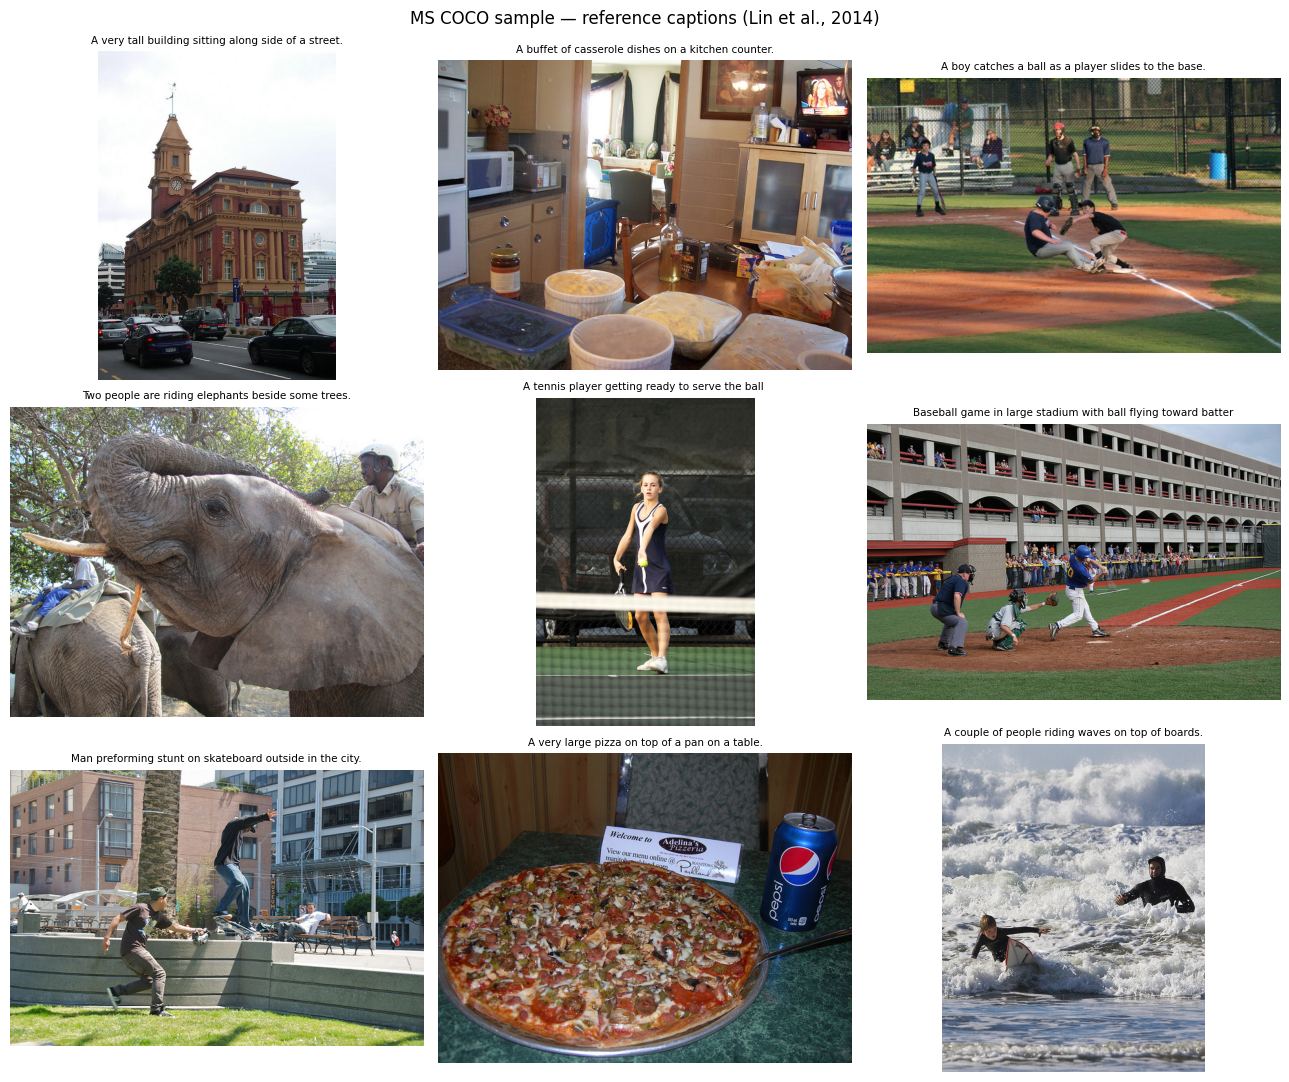


Sample grid saved to /content/drive/MyDrive/dissertation_final/results/week1_sample_grid.png


In [12]:
# ── CELL 12 — Plot sample grid (dissertation figure) ─────────────────────

def plot_sample_grid(df, n=9):
    sample = df.sample(n, random_state=RANDOM_SEED)
    fig, axes = plt.subplots(3, 3, figsize=(13, 11))
    axes = axes.flatten()
    for i, (_, row) in enumerate(sample.iterrows()):
        img = Image.open(row['img_path']).convert('RGB')
        axes[i].imshow(img)
        caps = row['captions']
        cap  = caps[0] if isinstance(caps, list) else caps.split(' | ')[0]
        axes[i].set_title(
            (cap[:65] + '...') if len(cap) > 65 else cap,
            fontsize=7.5, wrap=True
        )
        axes[i].axis('off')
    plt.suptitle('MS COCO sample — reference captions (Lin et al., 2014)', fontsize=12)
    plt.tight_layout()
    out = os.path.join(RESULTS_DIR, 'week1_sample_grid.png')
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\nSample grid saved to {out}')

plot_sample_grid(df)

In [13]:
# ── CELL 13 — Verify all outputs saved correctly ──────────────────────────

print('=' * 55)
print('Week 1 — Final verification')
print('=' * 55)

files_to_check = [
    f'{OUTPUT_DIR}/train.csv',
    f'{OUTPUT_DIR}/val.csv',
    f'{OUTPUT_DIR}/test.csv',
    f'{RESULTS_DIR}/week1_sample_grid.png',
]

all_ok = True
for fpath in files_to_check:
    exists = os.path.exists(fpath)
    size   = os.path.getsize(fpath) if exists else 0
    status = 'OK' if exists else 'MISSING'
    print(f'  [{status}] {os.path.basename(fpath):35s} {size:>10,} bytes')
    if not exists:
        all_ok = False

print()
if all_ok:
    train_df = pd.read_csv(f'{OUTPUT_DIR}/train.csv')
    val_df   = pd.read_csv(f'{OUTPUT_DIR}/val.csv')
    test_df  = pd.read_csv(f'{OUTPUT_DIR}/test.csv')
    print(f'  train.csv : {len(train_df)} rows x {len(train_df.columns)} columns')
    print(f'  val.csv   : {len(val_df)} rows x {len(val_df.columns)} columns')
    print(f'  test.csv  : {len(test_df)} rows x {len(test_df.columns)} columns')
    print()
    print('Week 1 complete. Open week1_model.ipynb next.')
else:
    print('Some files are missing. Re-run the cells above.')

Week 1 — Final verification
  [OK] train.csv                              302,367 bytes
  [OK] val.csv                                 37,928 bytes
  [OK] test.csv                                38,190 bytes
  [OK] week1_sample_grid.png                4,475,823 bytes

  train.csv : 800 rows x 5 columns
  val.csv   : 100 rows x 5 columns
  test.csv  : 100 rows x 5 columns

Week 1 complete. Open week1_model.ipynb next.


In [14]:
# ── CELL 14 — COCODataset class (used in later weeks) ────────────────────
# Define this class here so it can be imported in later notebooks.

class COCODataset:
    """
    Lightweight dataset wrapper used across all weeks.
    Literature note: Following Suzuki & Matsuo (2022), each image is
    the primary modality and captions are the paired text modality.
    5 reference captions per image enable robust multi-reference BLEU.
    """
    def __init__(self, csv_path: str):
        self.df = pd.read_csv(csv_path)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int):
        row      = self.df.iloc[idx]
        img      = Image.open(row['img_path']).convert('RGB')
        captions = row['captions'].split(' | ')
        return img, captions

    def get_path(self, idx: int) -> str:
        return self.df.iloc[idx]['img_path']

# Quick test
dataset = COCODataset(f'{OUTPUT_DIR}/test.csv')
img, caps = dataset[0]
print(f'COCODataset test:')
print(f'  Dataset size    : {len(dataset)}')
print(f'  Image size      : {img.size}')
print(f'  Sample caption  : {caps[0]}')
print(f'  Num captions    : {len(caps)}')
print('\nCOCODataset class ready for use in later notebooks.')

COCODataset test:
  Dataset size    : 100
  Image size      : (640, 426)
  Sample caption  : Three people are playing with a red kick ball.
  Num captions    : 5

COCODataset class ready for use in later notebooks.
